<a href="https://colab.research.google.com/github/tatyanalitvin/python_for_ds_tasks/blob/dev/HW_2_1_%D0%9B%D1%96%D0%BD%D1%96%D0%B9%D0%BD%D0%B0_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F_%D0%B2%D1%96%D0%B4_%D0%B1%D0%B0%D0%B3%D0%B0%D1%82%D1%8C%D0%BE%D1%85_%D0%B7%D0%BC%D1%96%D0%BD%D0%BD%D0%B8%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [1]:
import pandas as pd
import numpy as np

import plotly.express as px
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error

import statsmodels.api as sm

from IPython.display import display


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Знайомство з даними

**Завдання 1.**
Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [3]:
path = f"/content/drive/MyDrive/Colab Notebooks/ML for People/Data/cars.csv"
cars_df = pd.read_csv(path)
cars_df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [4]:
# приклад як викликати документацію, якщо у Вас pandas імпортований як pd
?pd.DataFrame.info

In [5]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [6]:
cars_df.dtypes

,0
Car_ID,int64
Brand,object
Model,object
Year,int64
Kilometers_Driven,int64
Fuel_Type,object
Transmission,object
Owner_Type,object
Mileage,int64
Engine,int64


In [7]:
for c in cars_df.select_dtypes('object').columns:
  print(c)
  print(cars_df[c].unique())
  print()

Brand
['Toyota' 'Honda' 'Ford' 'Maruti' 'Hyundai' 'Tata' 'Mahindra' 'Volkswagen'
 'Audi' 'BMW' 'Mercedes']

Model
['Corolla' 'Civic' 'Mustang' 'Swift' 'Sonata' 'Nexon' 'Scorpio' 'Polo'
 'A4' 'X1' 'C-Class' 'Endeavour' 'Creta' 'Harrier' 'Ertiga' 'City'
 'Tiguan' 'Q3' '5 Series' 'GLC' 'Innova' 'Figo' 'Verna' 'Altroz' 'Thar'
 'Passat' 'A6' 'X3' 'E-Class' 'Fortuner' 'Aspire' 'Elantra' 'Safari'
 'Vitara' 'WR-V' 'Ameo' 'A3' '7 Series' 'GLE' 'Yaris' 'Ranger' 'Santro'
 'Tigor' 'S-Cross' 'BR-V' 'T-Roc' 'Q7' 'X5' 'GLA' 'Camry' 'Venue' 'Tiago'
 'XUV300' 'Vento' 'A5' '3 Series' 'Innova Crysta' 'EcoSport']

Fuel_Type
['Petrol' 'Diesel']

Transmission
['Manual' 'Automatic']

Owner_Type
['First' 'Second' 'Third']



In [ ]:
num_cols = cars_df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = cars_df.select_dtypes(include=['object']).columns

binary_cols = [c for c in cat_cols if cars_df[c].nunique() == 2]
multi_cols = [c for c in cat_cols if cars_df[c].nunique() > 2]

conclusion = f"""
Висновок

У наборі даних:
- {len(num_cols)} числових колонок:
  {list(num_cols)}

- {len(cat_cols)} категоріальних колонок:
  {list(cat_cols)}

Серед категоріальних:
- {len(binary_cols)} бінарні (мають лише 2 значення):
  {binary_cols}

- {len(multi_cols[:-1])} 2 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
  {multi_cols[:-1]}

- 1 колонка, в якій можна встановити відношення порядку (наприклад Small<Medium<Large)
  {'Owner_Type'} зі значеннями:
  {cars_df['Owner_Type'].unique()}
"""

print(conclusion)



Висновок

У наборі даних:
- 8 числових колонок:
  ['Car_ID', 'Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Price']

- 5 категоріальних колонок:
  ['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Owner_Type']

Серед категоріальних:
- 2 бінарні (мають лише 2 значення):
  ['Fuel_Type', 'Transmission']

- 3 2 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
  ['Brand', 'Model']

- 1 колонка, в якій можна встановити відношення порядку (наприклад Small<Medium<Large)
  Owner_Type зі значеннями:
  ['First' 'Second' 'Third']



**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [9]:
X = cars_df.drop('Price', axis=1)
y = cars_df['Price']

random_state = 12

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = random_state
    )

**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

In [10]:
def apply_one_hot_encoding_custom(
    df: pd.DataFrame,
    column_name: str,
    codes: dict = None,
    ):
  if not codes:
    idx_of_min = df[column_name].value_counts().idxmin()
    idx_of_max = df[column_name].value_counts().idxmax()
    codes = {idx_of_min: 0, idx_of_max: 1}
    print(codes)

  df[f'is_{next(k for k,v in codes.items() if v==1)}_{column_name}'] = df[column_name].map(codes)

In [11]:
# 1.Закодуйте колонки з бінарними значеннями Fuel_Type і Transmission так,
# аби вони були у чисельному представленні і містили лише 0 так 1.
# Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

fig = px.histogram(X_train, x='Fuel_Type', color='Fuel_Type')
fig.show()


In [12]:
apply_one_hot_encoding_custom(X_train, 'Fuel_Type')
X_train['is_Petrol_Fuel_Type'].value_counts()

{'Diesel': 0, 'Petrol': 1}


,count
is_Petrol_Fuel_Type,
1,41
0,39


In [13]:
apply_one_hot_encoding_custom(X_test, 'Fuel_Type', codes = {'Diesel': 0, 'Petrol': 1})
X_test['is_Petrol_Fuel_Type'].value_counts()

,count
is_Petrol_Fuel_Type,
1,11
0,9


In [14]:
fig = px.histogram(X_train, x='Transmission', color='Transmission')
fig.show()

In [15]:
apply_one_hot_encoding_custom(X_train, 'Transmission')
X_train['is_Automatic_Transmission'].value_counts()

{'Manual': 0, 'Automatic': 1}


,count
is_Automatic_Transmission,
1,49
0,31


In [16]:
apply_one_hot_encoding_custom(X_test, 'Transmission', codes = {'Manual': 0, 'Automatic': 1})
X_test['is_Automatic_Transmission'].value_counts()

,count
is_Automatic_Transmission,
0,12
1,8


In [17]:
# Закодуйте колонку Brand з використанням sklearn.preprocessing.OneHotEncoder аналогічно до того,
# як ми робили це в лекції. Увага! Ми робимо виклик методу Encoder.fit() на тренувальних даних X_train,
# а на тестувальних тільки викликаємо Encoder.transform(). Додайте закодовані значення в набори даних X_train, X_test.
fig = px.histogram(X_train, x='Brand', color='Brand')
fig.show()

one_hot_enc = OneHotEncoder()
one_hot_enc.fit(X_train[['Brand']])
print(f"Categories:")
display(one_hot_enc.categories_)

print(f"\n\n\nTRAIN:")
X_train[one_hot_enc.categories_[0]] = one_hot_enc.transform(X_train[['Brand']]).toarray()
display(X_train.head())

print(f"\n\n\nTEST:")
X_test[one_hot_enc.categories_[0]] = one_hot_enc.transform(X_test[['Brand']]).toarray()
display(X_test.head())

Categories:


[array(['Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti',
        'Mercedes', 'Tata', 'Toyota', 'Volkswagen'], dtype=object)]




TRAIN:


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,...,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0





TEST:


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,...,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

In [19]:
# Колонка Model містять забагато значень для кодування в тому вигляді, як вона є зараз,
# з огляду на невелику кількість даних.
# Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5,
# то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал,
# якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

fig = px.histogram(X_train, x='Model', color='Model')
fig.show()
# X_train["Model"].value_counts()

In [20]:
# Ідея №1 -> згрупувати по типу автомобіля (спортивний, позашляховик, пікап та інше)
# була ще думка групувати по розміру, тому мітки з дослідження залишила, але на мою думку,
# по типу має бути більш інформативно
car_type = {
    "SUV": [
        "Q7", "X5", "GLE", "Fortuner", "Endeavour", "Safari", # large
        "X3", "GLC", "Harrier", "T-Roc", "Scorpio", "Thar", # medium
        "EcoSport", "BR-V", "WR-V", "S-Cross", "Vitara", "Nexon", "XUV300", "Venue", "GLA", # compact
        ],
    "Sedan": [
        "7 Series", "5 Series", "3 Series", "E-Class", "C-Class", "A6", "A5", "A3", "Passat", "Camry", "Sonata", # large
        "Elantra", "Civic", "Verna", "Corolla", # medium
        "Tigor", "Ameo", "Aspire", "Vento", # compact
        ],
    "Hatchback": [
        "Altroz", "Swift", "Yaris", # medium
        "Santro", "Tiago", # compact
        ],
    "MPV": ["Innova", "Innova Crysta"],  # large
    "Sports Car": ["Mustang"], # pony
}

def map_model(model):
    for c_type, models in car_type.items():
        if model in models:
            return c_type
    return "Other"


X_train["Model_Type"] = X_train["Model"].apply(map_model)
X_test["Model_Type"]  = X_test["Model"].apply(map_model)

In [21]:
fig = px.histogram(X_train, x='Model_Type', color='Model_Type')
fig.show()

one_hot_enc = OneHotEncoder()
one_hot_enc.fit(X_train[['Model_Type']])
print(f"Categories:")
display(one_hot_enc.categories_)

print(f"\n\n\nTRAIN:")
X_train[one_hot_enc.categories_[0]] = one_hot_enc.transform(X_train[['Model_Type']]).toarray()
display(X_train.head())

print(f"\n\n\nTEST:")
X_test[one_hot_enc.categories_[0]] = one_hot_enc.transform(X_test[['Model_Type']]).toarray()
display(X_test.head())

Categories:


[array(['Hatchback', 'MPV', 'Other', 'SUV', 'Sedan', 'Sports Car'],
       dtype=object)]




TRAIN:


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,...,Toyota,Volkswagen,Owner_Type_Codes,Model_Type,Hatchback,MPV,Other,SUV,Sedan,Sports Car
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,...,0.0,1.0,1.0,SUV,0.0,0.0,0.0,1.0,0.0,0.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,...,0.0,0.0,0.0,Sedan,0.0,0.0,0.0,0.0,1.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,...,0.0,0.0,0.0,Sedan,0.0,0.0,0.0,0.0,1.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,...,0.0,1.0,1.0,Sedan,0.0,0.0,0.0,0.0,1.0,0.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,...,0.0,0.0,1.0,SUV,0.0,0.0,0.0,1.0,0.0,0.0





TEST:


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,...,Toyota,Volkswagen,Owner_Type_Codes,Model_Type,Hatchback,MPV,Other,SUV,Sedan,Sports Car
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,...,0.0,0.0,1.0,Other,0.0,0.0,1.0,0.0,0.0,0.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,...,0.0,0.0,2.0,Hatchback,1.0,0.0,0.0,0.0,0.0,0.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,...,0.0,1.0,1.0,Sedan,0.0,0.0,0.0,0.0,1.0,0.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,...,0.0,0.0,0.0,Other,0.0,0.0,1.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,...,0.0,0.0,2.0,Sedan,0.0,0.0,0.0,0.0,1.0,0.0


In [22]:
# Ідея №2 -> ще думала, що можна було б згрупувати по count, то було б швидше і без необхідності шукати як змапити типи та моделі, але воно якость не так надійно звучить

Очікуваний результат після трансформацій:

In [23]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,is_Petrol_Fuel_Type,is_Automatic_Transmission,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Type,Hatchback,MPV,Other,SUV,Sedan,Sports Car
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,SUV,0.0,0.0,0.0,1.0,0.0,0.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sedan,0.0,0.0,0.0,0.0,1.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sedan,0.0,0.0,0.0,0.0,1.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Sedan,0.0,0.0,0.0,0.0,1.0,0.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,SUV,0.0,0.0,0.0,1.0,0.0,0.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,is_Petrol_Fuel_Type,is_Automatic_Transmission,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Type,Hatchback,MPV,Other,SUV,Sedan,Sports Car
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Other,0.0,0.0,1.0,0.0,0.0,0.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Hatchback,1.0,0.0,0.0,0.0,0.0,0.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Sedan,0.0,0.0,0.0,0.0,1.0,0.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Other,0.0,0.0,1.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Sedan,0.0,0.0,0.0,0.0,1.0,0.0


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [24]:
X_train_num = X_train.select_dtypes(include=["int64", "float64"])
X_test_num = X_test.select_dtypes(include=["int64", "float64"])

pd.concat([X_train_num, y_train], axis=1).corr()

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,is_Petrol_Fuel_Type,is_Automatic_Transmission,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Hatchback,MPV,Other,SUV,Sedan,Sports Car,Price
Car_ID,1.000000,0.137027,-0.356614,0.100891,-0.089284,-0.006319,-0.063793,0.090537,-0.084381,0.089473,0.048335,-0.020240,-0.050809,0.016831,0.006797,-0.054463,-0.045431,-0.032926,0.011350,0.020129,0.038923,0.098318,0.033068,0.038733,-0.020088,-0.048021,-0.038377,0.025560
Year,0.137027,1.000000,-0.708525,0.278559,-0.392764,-0.248442,-0.278755,0.248515,-0.200603,-0.256523,0.202517,-0.150454,-0.037437,-0.092099,0.181669,0.285094,-0.115157,0.248715,-0.219346,0.018255,-0.014499,0.449845,-0.123230,-0.194667,0.023506,-0.195791,-0.005137,-0.233769
Kilometers_Driven,-0.356614,-0.708525,1.000000,-0.126621,0.101219,-0.060803,0.403656,-0.332351,-0.066491,0.095879,-0.247042,-0.009761,0.057372,0.154362,-0.040344,-0.190420,-0.091731,0.030399,0.368519,-0.137675,-0.001772,-0.285818,0.273077,0.168300,-0.058048,0.151375,-0.151311,-0.083951
Mileage,0.100891,0.278559,-0.126621,1.000000,-0.710516,-0.684705,-0.178619,-0.070112,-0.399164,-0.152701,-0.134105,-0.296480,0.358630,0.217406,0.029427,0.116389,-0.238489,0.347678,-0.201565,0.085114,0.026624,0.360374,-0.190723,-0.237671,-0.097244,0.127173,-0.292970,-0.638404
Engine,-0.089284,-0.392764,0.101219,-0.710516,1.000000,0.801638,0.167326,-0.174455,0.456296,0.085153,0.287119,0.184231,-0.154491,-0.182213,-0.024973,-0.193257,0.163871,-0.340051,0.234889,-0.165115,-0.196106,-0.346480,0.205859,0.070044,0.084818,-0.106326,0.374785,0.710561
Power,-0.006319,-0.248442,-0.060803,-0.684705,0.801638,1.000000,-0.139388,0.076357,0.586910,0.157050,0.372652,0.240501,-0.191810,-0.170966,-0.118021,-0.220984,0.280827,-0.316989,-0.040478,-0.148437,-0.204309,-0.339839,0.008088,-0.017478,0.004900,-0.008900,0.554604,0.849137
Seats,-0.063793,-0.278755,0.403656,-0.178619,0.167326,-0.139388,1.000000,-0.412468,-0.070099,0.123674,-0.108079,-0.161451,0.200303,-0.086439,0.007738,-0.078379,-0.108079,-0.012748,0.348535,-0.094002,-0.043849,-0.101187,0.383470,-0.048609,0.328019,-0.247858,-0.326225,0.000979
is_Petrol_Fuel_Type,0.090537,0.248515,-0.332351,-0.070112,-0.174455,0.076357,-0.412468,1.000000,-0.005775,-0.008336,-0.048475,0.109812,-0.161425,-0.007121,-0.235225,0.148511,-0.048475,0.066164,-0.008336,0.125010,0.281122,0.241742,-0.164183,-0.164183,-0.097154,-0.020419,0.192511,-0.110782
is_Automatic_Transmission,-0.084381,-0.200603,-0.066491,-0.399164,0.456296,0.586910,-0.070099,-0.005775,1.000000,0.265132,0.283188,-0.122816,-0.218620,0.031659,-0.170703,-0.112622,0.283188,-0.397609,-0.076974,0.155500,0.005886,-0.419079,-0.201319,-0.201319,-0.063196,0.387567,0.156999,0.680731
Audi,0.089473,-0.256523,0.095879,-0.152701,0.085153,0.157050,0.123674,-0.008336,0.265132,1.000000,-0.118678,-0.118678,-0.086066,-0.094916,-0.076472,-0.086066,-0.118678,-0.125988,-0.111111,-0.103221,-0.203925,-0.111111,-0.053376,-0.053376,-0.110031,0.238145,-0.065795,0.328858


In [25]:
corr = X_train_num.corrwith(y_train)

strong_corr = corr[abs(corr) > 0.5]
strong_corr

,0
Mileage,-0.638404
Engine,0.710561
Power,0.849137
is_Automatic_Transmission,0.680731


**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [26]:
model = LinearRegression().fit(X_train_num, y_train)

y_train_pred = model.predict(X_train_num)
loss_train = root_mean_squared_error(y_train, y_train_pred)

y_test_pred  = model.predict(X_test_num)
loss_test  = root_mean_squared_error(y_test, y_test_pred)

print(f"RMSE on train: {loss_train:.4f}")
print(f"RMSE on test:  {loss_test:.4f}")

RMSE on train: 185820.4062
RMSE on test:  244574.2382


In [27]:
display(model.intercept_)
display(model.coef_)
display(model.feature_names_in_)

np.float64(-71155442.12008543)

array([ 1.06490146e+02,  3.57851165e+04, -8.79423692e+00, -3.10432074e+04,
       -2.09631421e+01,  7.62710282e+03, -3.07318391e+03, -3.76851514e+05,
        1.63053035e+05,  7.06388531e+05,  5.69603021e+05, -1.52150979e+05,
       -2.46769023e+05, -4.18195312e+05, -6.43552697e+05, -3.63754167e+05,
        6.32515789e+05, -1.68694259e+05,  2.62066017e+05, -1.77456920e+05,
        3.92838112e+02,  1.55715324e+05, -3.44036393e+05,  1.85291121e+05,
        2.47894856e+05,  2.10953704e+05, -4.55818613e+05])

array(['Car_ID', 'Year', 'Kilometers_Driven', 'Mileage', 'Engine',
       'Power', 'Seats', 'is_Petrol_Fuel_Type',
       'is_Automatic_Transmission', 'Audi', 'BMW', 'Ford', 'Honda',
       'Hyundai', 'Mahindra', 'Maruti', 'Mercedes', 'Tata', 'Toyota',
       'Volkswagen', 'Owner_Type_Codes', 'Hatchback', 'MPV', 'Other',
       'SUV', 'Sedan', 'Sports Car'], dtype=object)

In [28]:
weights_df = pd.DataFrame({
    'feature': np.append(model.feature_names_in_, 1),
    'weight': np.append(model.coef_, model.intercept_),
}).set_index('feature')
weights_df.sort_values('weight', ascending=False)

,weight
feature,
Audi,7.063885e+05
Mercedes,6.325158e+05
BMW,5.696030e+05
Toyota,2.620660e+05
SUV,2.478949e+05
Sedan,2.109537e+05
Other,1.852911e+05
is_Automatic_Transmission,1.630530e+05
Hatchback,1.557153e+05


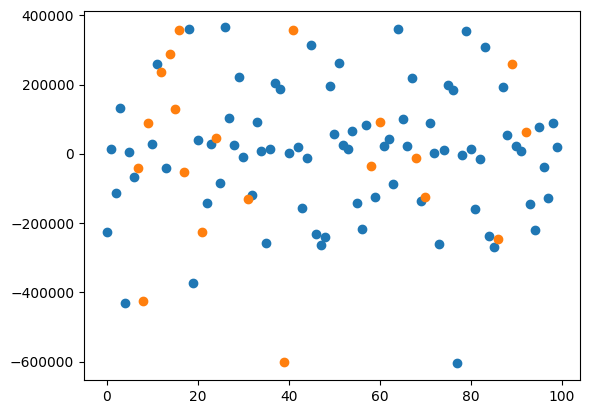

In [29]:
#Errors
train_errors = y_train - y_train_pred
plt.plot(train_errors, 'o')
test_errors = y_test - y_test_pred
plt.plot(test_errors, 'o')

(array([1., 1., 0., 2., 2., 3., 3., 3., 2., 3.]),
 array([-601397.87257177, -505385.13082144, -409372.38907111,
        -313359.64732078, -217346.90557045, -121334.16382012,
         -25321.42206979,   70691.31968054,  166704.06143087,
         262716.8031812 ,  358729.54493153]),
 <BarContainer object of 10 artists>)

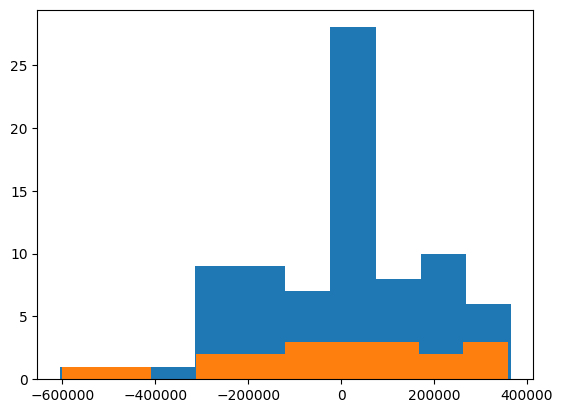

In [30]:
plt.hist(train_errors)
plt.hist(test_errors)

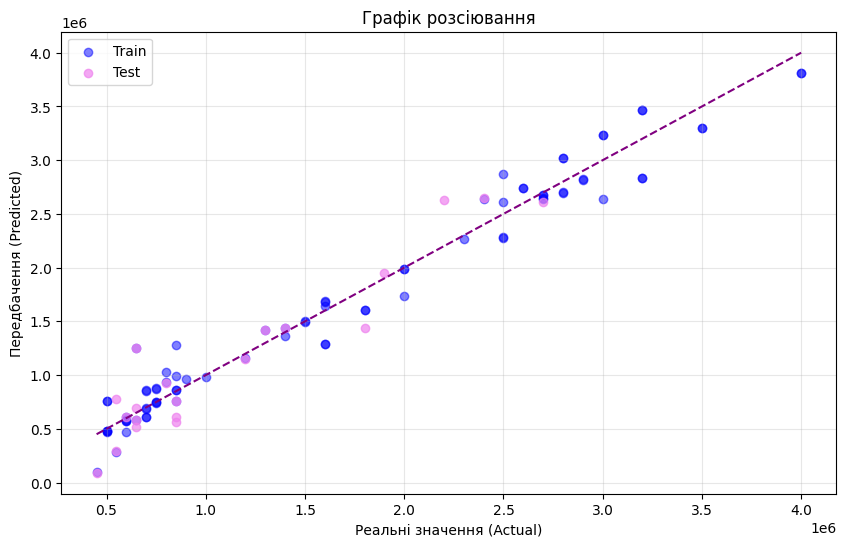

In [31]:
plt.figure(figsize=(10, 6))
plt.scatter(y_train, y_train_pred, alpha=0.5, label='Train', color='blue')
plt.scatter(y_test, y_test_pred, alpha=0.7, label='Test', color='violet')

min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color='purple', linestyle='--')

plt.title('Графік розсіювання')
plt.xlabel('Реальні значення (Actual)')
plt.ylabel('Передбачення (Predicted)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Судячи з графіку модель виглядає непогано, точки формуються у діагональ і для тренувального, і для тестового набору

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [32]:
numeric_ls = ['Car_ID', 'Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats']
categorical_encoded_ls = ['is_Petrol_Fuel_Type', 'is_Automatic_Transmission', 'Audi',
       'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti', 'Mercedes',
       'Tata', 'Toyota', 'Volkswagen', 'Owner_Type_Codes', 'Hatchback', 'MPV',
       'Other', 'SUV', 'Sedan', 'Sports Car']

std_scaler = StandardScaler()
std_scaler.fit(X_train_num[numeric_ls])

X_train_num_scaled = pd.DataFrame(
    std_scaler.transform(X_train_num[numeric_ls]),
    columns=numeric_ls,
    index=X_train_num.index
)
X_test_num_scaled = pd.DataFrame(
    std_scaler.transform(X_test_num[numeric_ls]),
    columns=numeric_ls,
    index=X_test_num.index
)

X_train_num_scaled[categorical_encoded_ls] = X_train_num[categorical_encoded_ls]
X_test_num_scaled[categorical_encoded_ls] = X_test_num[categorical_encoded_ls]

In [33]:
model = LinearRegression().fit(X_train_num_scaled, y_train)

y_train_pred = model.predict(X_train_num_scaled)
loss_train = root_mean_squared_error(y_train, y_train_pred)

y_test_pred  = model.predict(X_test_num_scaled)
loss_test  = root_mean_squared_error(y_test, y_test_pred)

print(f"RMSE on train: {loss_train:.4f}")
print(f"RMSE on test:  {loss_test:.4f}")

RMSE on train: 185820.4062
RMSE on test:  244574.2382


In [34]:
weights_df = pd.DataFrame({
    'feature': np.append(model.feature_names_in_, 1),
    'weight': np.append(model.coef_, model.intercept_),
}).set_index('feature')
weights_df.sort_values('weight', ascending=False).round(3)

,weight
feature,
1,1515210.669
Audi,706388.531
Mercedes,632515.789
Power,621023.697
BMW,569603.021
Toyota,262066.017
SUV,247894.856
Sedan,210953.704
Other,185291.121


суттєво збільшують ціну:

* бренд Audi додає до ціни 706388.531
* бренд Mercedes додає до ціни 632515.789
* Power 621023.697
* BMW 569603.021 ще один преміум-бренд.
* Toyota 262066.017 та SUV 247894.856 також суттєво піднімають ціну.

суттєво зменшують ціну:

* Mahindra -643552.697 "тягне" ціну вниз
* Sports Car -455818.613
* Hyundai -418195.312
* is_Petrol_Fuel_Type -376851.514: Бензинові авто дешевші за дизельні -  виглядає дещо дивно
* Maruti -363754.167
* MPV	-344036.393
* Honda	-246769.023


**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [35]:
X_train_num_scaled = sm.add_constant(X_train_num_scaled)
model = sm.OLS(y_train, X_train_num_scaled)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                     64.71
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           8.53e-32
Time:                        16:09:01   Log-Likelihood:                -1084.1
No. Observations:                  80   AIC:                             2220.
Df Residuals:                      54   BIC:                             2282.
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

* Коефіцієнт детермінації R-squared = 0.968, він вказує що модель пояснює ~96.8 дисперсії ціни.
* Скоригований R2 Adj. R-squared = 0.953, він враховує кількість ознак. Він також високий і близький до звичайного R2 -> що у моделі небагато зайвих ознак, шуму майже нема.
* Загальна значущість моделі Prob (F-statistic) = 8.53e-32, що набагато менше 0.05 і дуже близько до 0, отже модель в цілому є статистично значущою.
* P-value > |t|  показує ймовірність того, що зв'язок між ознакою і ціною є випадковим на рівені значущості 0.05:
  * Якщо P < 0.05 , ознака вважається статистично значущою.
  * Якщо P > 0.05, ознака статистично не значуща -> її вплив на ціну не доведений на даних даних.

In [36]:
results.pvalues[results.pvalues <= 0.05].round(3)

,0
const,0.000
Power,0.000
is_Petrol_Fuel_Type,0.000
Audi,0.000
BMW,0.000
Hyundai,0.005
Mahindra,0.000
Maruti,0.032
Mercedes,0.000
Toyota,0.003


In [37]:
results.pvalues[results.pvalues > 0.05].round(3)

,0
Car_ID,0.926
Year,0.498
Kilometers_Driven,0.219
Mileage,0.093
Engine,0.842
Seats,0.961
is_Automatic_Transmission,0.106
Ford,0.751
Honda,0.319
Tata,0.626


In [38]:
significant_features_05_lvl_ls = results.pvalues[results.pvalues <= 0.05].index.tolist()
significant_features_05_lvl_ls

['const',
 'Power',
 'is_Petrol_Fuel_Type',
 'Audi',
 'BMW',
 'Hyundai',
 'Mahindra',
 'Maruti',
 'Mercedes',
 'Toyota',
 'Hatchback',
 'SUV',
 'Sedan']

In [39]:
significant_features_25_lvl_ls = results.pvalues[results.pvalues <= 0.25].index.tolist()
significant_features_25_lvl_ls

['const',
 'Kilometers_Driven',
 'Mileage',
 'Power',
 'is_Petrol_Fuel_Type',
 'is_Automatic_Transmission',
 'Audi',
 'BMW',
 'Hyundai',
 'Mahindra',
 'Maruti',
 'Mercedes',
 'Toyota',
 'Hatchback',
 'Other',
 'SUV',
 'Sedan']

**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [40]:
X_train_num_scaled_05 = sm.add_constant(X_train_num_scaled[significant_features_05_lvl_ls])
model = sm.OLS(y_train, X_train_num_scaled_05)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.939
Method:                 Least Squares   F-statistic:                     102.5
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           3.22e-38
Time:                        16:09:01   Log-Likelihood:                -1102.9
No. Observations:                  80   AIC:                             2232.
Df Residuals:                      67   BIC:                             2263.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                1.212e+06   1

  * R-squared знизився з 0.968 до 0.948
  * Adj. R-squared знизився з 0.953 до 0.939
  * Ця модель відкинула частину корисної інформації, фічі, які були більш значущі у наборі з попереднього завдання, втратили значущість на рівні 0.05.

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [41]:
X_train_num_scaled_25 = sm.add_constant(X_train_num_scaled[significant_features_25_lvl_ls])
model = sm.OLS(y_train, X_train_num_scaled_25)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.958
Method:                 Least Squares   F-statistic:                     114.9
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           2.74e-40
Time:                        16:09:01   Log-Likelihood:                -1085.1
No. Observations:                  80   AIC:                             2204.
Df Residuals:                      63   BIC:                             2245.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

Модель стала простішою, але не втратила в якості передбачення:
* R-squared: 0.967 (лише на 0.001 менше за модель з повним набором фіч)
* Adj. R-squared: 0.958 (зріс, був 0.953)

Я б використовувала цю модель, в ній оптимізована кількість фіч та результат